# Challenge: Edit MNIST challenge images to be correctly predicted

Goal: Edit the images placed in `data/MNIST/challenge` so that the provided model predicts the correct label while keeping more than 60% of the original pixels unchanged.

Description: You are given a pre-trained `SmallCNN` model and a small set of challenge images. Your task is to minimally modify these images so the model classifies them correctly. This exercise encourages you to: 
- Explore the sample dataset in `data/MNIST/sample` to understand variation and typical inputs.
- Use explainable AI (XAI) techniques (saliency maps, Grad-CAM, Integrated Gradients, occlusion, etc.) to discover what parts of the image the model relies on.
- Propose minimal edits (pixel changes, small masks, subtle color shifts) that change model prediction while preserving at least 60% of the original pixels.

Deliverables: For each edited image, save the modified image to `data/MNIST/challenge/edited/` alongside a short report (less than 2 pages) describing the XAI insights you used and the percentage of pixels preserved. For ease of use, you have the images already in that folder and you can directly work on them. You are allowed to use any external program you want to modify the image (i.e., paint, photoshop, figma, ...).

The practice can be done by more than 1 person. Final grade would depend on the number of images correctly edited (n_images_correct) with their corresponding report and number of persons working together (n_persons) following the next formula:
$$grade = 2,5 \times n\_images\_correct - 2,5 * (n\_persons - 1)$$


In [80]:
# Imports and device
import torch
import torch.nn as nn
from torchvision import transforms
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [81]:
# SmallCNN definition (must match the trained model architecture)
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(12*7*7, 12)
        self.fc2 = nn.Linear(12, num_classes)

    def forward(self, x):
        x = self.pool(torch.nn.functional.relu(self.conv1(x)))  # 14x14
        x = self.pool(x)                      # 7x7
        x = x.view(x.size(0), -1)
        x = self.dropout(torch.nn.functional.relu(self.fc1(x)))
        return self.fc2(x)

# convenience transform
to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()

In [82]:
models_dir = Path('../models')
model_name = models_dir / 'small_cnn.pth'
model = torch.load(model_name, weights_only=False)
model.to(device) 
model.eval()

SmallCNN(
  (conv1): Conv2d(3, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=588, out_features=12, bias=True)
  (fc2): Linear(in_features=12, out_features=10, bias=True)
)

0_label5.png: Pred: 1, Label: 5
1_label3.png: Pred: 1, Label: 3
2_label3.png: Pred: 1, Label: 3
3_label7.png: Pred: 3, Label: 7
4_label2.png: Pred: 6, Label: 2


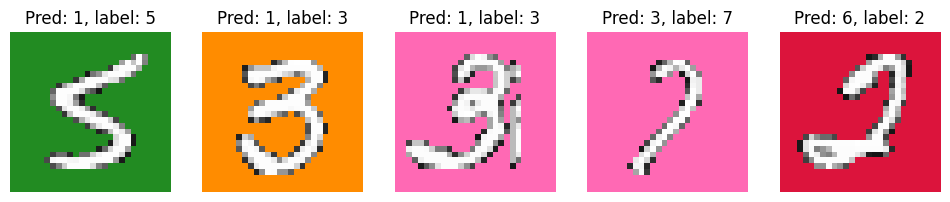

In [83]:
# Load the images in data/MNIST/challenge/ and plot them. Label of the image is the last character of the filename.
challenge_dir = Path('../data/MNIST/challenge')
image_files = list(challenge_dir.glob('*.png'))
fig, axes = plt.subplots(1, len(image_files), figsize=(12,4))
for ax, img_file in zip(axes, image_files):
    img = to_tensor(Image.open(img_file)).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img)
        pred = output.argmax(dim=1).item()
    ax.imshow(to_pil(img.squeeze().cpu()))
    ax.set_title(f'Pred: {pred}, label: {img_file.stem[-1]}')
    ax.axis('off')
    print(f'{img_file.name}: Pred: {pred}, Label: {img_file.stem[-1]}')
plt.show()

---
### Any code you want to add, put it below this markdown cell

0_label5.png: Pred=1, Label=5


C:\Users\jga20\AppData\Local\Temp\ipykernel_20112\2561352083.py:29: RuntimeWarning: invalid value encountered in divide
  saliency /= saliency.max()
c:\Users\jga20\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


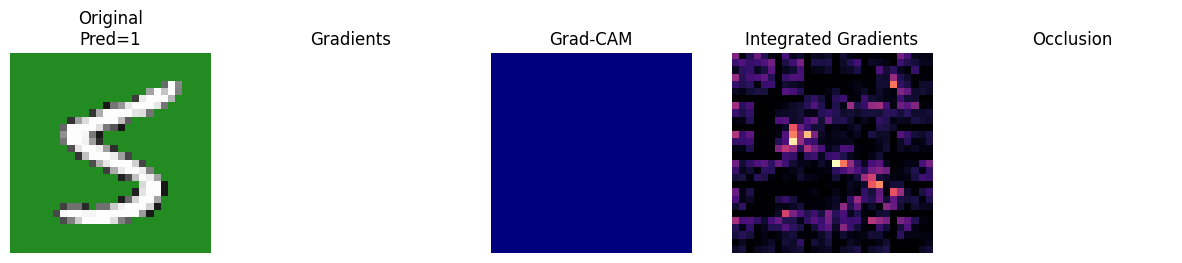

1_label3.png: Pred=1, Label=3


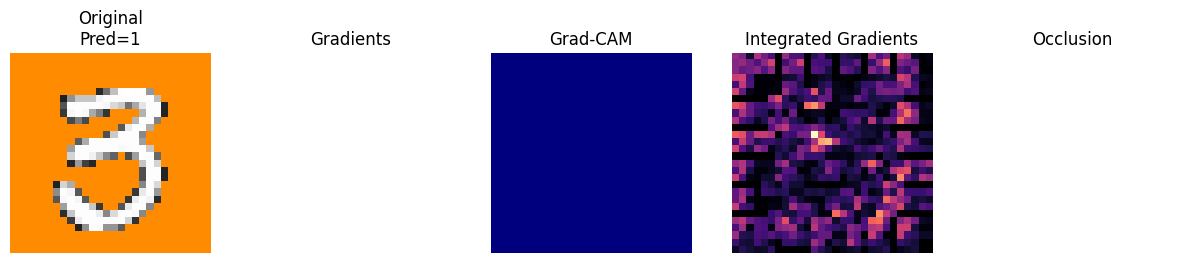

2_label3.png: Pred=1, Label=3


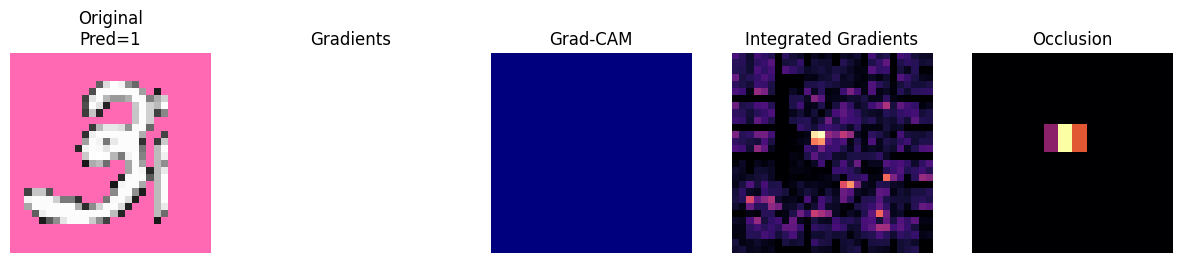

3_label7.png: Pred=3, Label=7


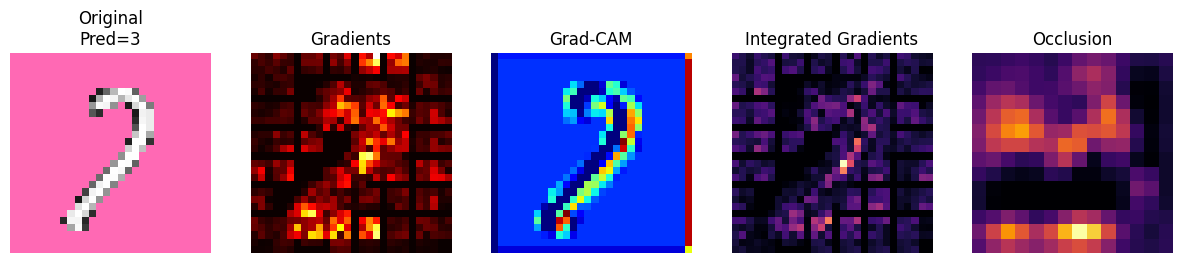

4_label2.png: Pred=6, Label=2


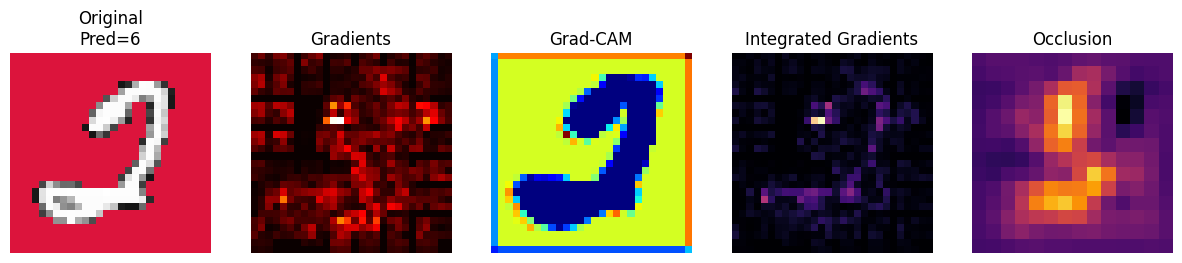

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path


challenge_dir = Path('../data/MNIST/challenge')
image_files = list(challenge_dir.glob('*.png'))

def show_saliency_maps(model, img_path):
    model.eval()
    img = to_tensor(Image.open(img_path)).unsqueeze(0).to(device)
    img.requires_grad_()

    output = model(img)
    pred_class = output.argmax(dim=1).item()
    true_class = int(img_path.stem[-1])
    print(f"{img_path.name}: Pred={pred_class}, Label={true_class}")

    # Gradient Saliency Map
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    saliency = img.grad.abs().squeeze().cpu().numpy()
    saliency = saliency.max(axis=0) 
    saliency /= saliency.max()

    # Grad-CAM
    target_layer = model.conv1

    if hasattr(target_layer, "_backward_hooks"):
        target_layer._backward_hooks.clear()
    if hasattr(target_layer, "_forward_hooks"):
        target_layer._forward_hooks.clear()
    if hasattr(target_layer, "_forward_pre_hooks"):
        target_layer._forward_pre_hooks.clear()

    act = None
    grad = None

    def forward_hook(module, input, output):
        nonlocal act
        act = output.detach()

    def backward_hook(module, grad_input, grad_output):
        nonlocal grad
        grad = grad_output[0].detach()

    # Registrar hooks
    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_backward_hook(backward_hook)

    # Forward + backward
    out = model(img)
    model.zero_grad()
    out[0, pred_class].backward()

    if grad is None or act is None:
        raise RuntimeError("Grad-CAM hooks did not capture gradients properly.")

    # Calcular Grad-CAM
    weights = grad.mean(dim=(2, 3), keepdim=True)
    cam = (weights * act).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=(28, 28), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    h1.remove()
    h2.remove()

    # Integrated Gradients
    steps = 50
    baseline = torch.zeros_like(img)
    scaled_imgs = [baseline + (i / steps) * (img - baseline) for i in range(1, steps + 1)]

    grads = []
    for s_img in scaled_imgs:
        s_img = s_img.clone().detach().requires_grad_(True)
        output = model(s_img)
        score = output[0, pred_class]
        grad = torch.autograd.grad(outputs=score, inputs=s_img)[0]  
        grads.append(grad)

    avg_grads = torch.mean(torch.stack(grads), dim=0)
    ig = (img - baseline) * avg_grads
    ig = ig.abs().detach().squeeze().cpu().numpy().max(axis=0)
    ig = ig / (ig.max() + 1e-8)


    # Occlusion Sensitivity
    window_size = 4  # píxeles por lado del bloque
    stride = 2       # desplazamiento del bloque
    baseline_value = 0.0  # color gris oscuro

    _, _, H, W = img.shape
    heatmap = torch.zeros((H, W))

    with torch.no_grad():
        base_score = F.softmax(model(img), dim=1)[0, pred_class].item()

    for i in range(0, H - window_size + 1, stride):
        for j in range(0, W - window_size + 1, stride):
            occluded = img.clone()
            occluded[:, :, i:i+window_size, j:j+window_size] = baseline_value
            with torch.no_grad():
                occl_score = F.softmax(model(occluded), dim=1)[0, pred_class].item()
            delta = base_score - occl_score
            heatmap[i:i+window_size, j:j+window_size] += delta

    heatmap = heatmap / heatmap.max()
    heatmap = heatmap.cpu().numpy()

    # Añadimos al plot
    fig, axs = plt.subplots(1, 5, figsize=(15, 4))
    axs[0].imshow(to_pil(img.squeeze().cpu())); axs[0].set_title(f"Original\nPred={pred_class}")
    axs[1].imshow(saliency, cmap='hot'); axs[1].set_title("Gradients")
    axs[2].imshow(cam, cmap='jet'); axs[2].set_title("Grad-CAM")
    axs[3].imshow(ig, cmap='magma'); axs[3].set_title("Integrated Gradients")
    axs[4].imshow(heatmap, cmap='inferno'); axs[4].set_title("Occlusion")
    for ax in axs: ax.axis('off')
    plt.show()


for img_path in image_files:
    show_saliency_maps(model, img_path)


In [85]:
# Check percentage of editing an image
def calculate_edit_percentage(original_img, edited_img):
    original_pixels = original_img.load()
    edited_pixels = edited_img.load()
    width, height = original_img.size
    total_pixels = width * height
    changed_pixels = 0

    for x in range(width):
        for y in range(height):
            if original_pixels[x, y] != edited_pixels[x, y]:
                changed_pixels += 1

    return (changed_pixels / total_pixels) * 100

step   0: target prob=0.0941
✅ Target class 5 achieved at step 2
0_label5.png: True=5, Adv Pred=5, Target=5


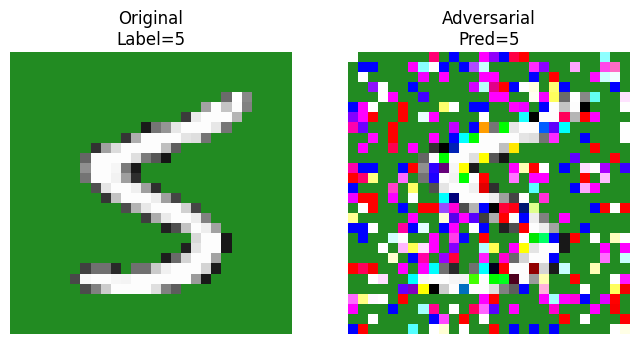

step   0: target prob=0.2589
step  10: target prob=0.1735
step  20: target prob=0.2112
✅ Target class 3 achieved at step 22
1_label3.png: True=3, Adv Pred=3, Target=3


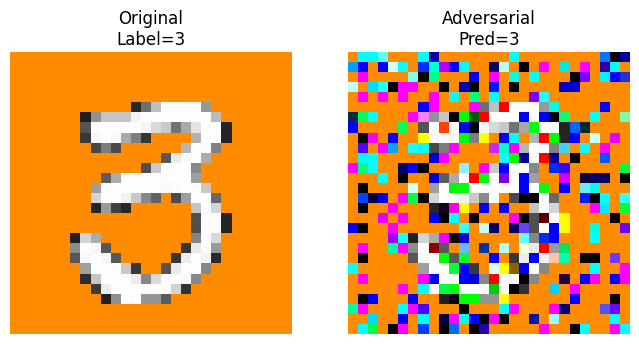

step   0: target prob=0.0517
step  10: target prob=0.0143
step  20: target prob=0.0002
step  30: target prob=0.0359
step  40: target prob=0.0020
step  50: target prob=0.2032
step  60: target prob=0.0022
step  70: target prob=0.1028
step  80: target prob=0.0238
step  90: target prob=0.0089
step 100: target prob=0.0910
step 110: target prob=0.0008
step 120: target prob=0.0008
step 130: target prob=0.0049
step 140: target prob=0.0272
step 150: target prob=0.0045
✅ Target class 3 achieved at step 158
2_label3.png: True=3, Adv Pred=3, Target=3


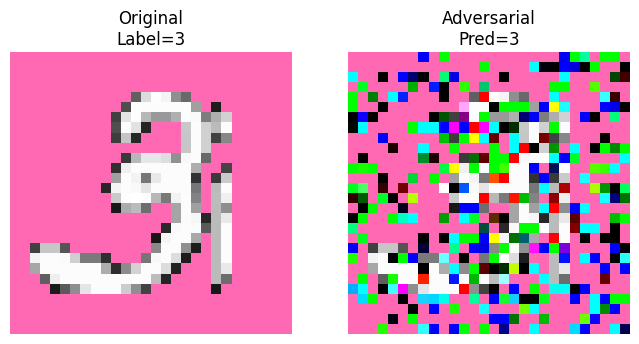

step   0: target prob=0.0000
step  10: target prob=0.0043
✅ Target class 7 achieved at step 12
3_label7.png: True=7, Adv Pred=7, Target=7


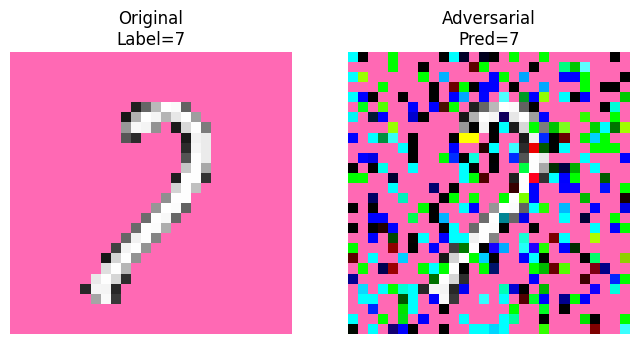

step   0: target prob=0.6580
✅ Target class 2 achieved at step 0
4_label2.png: True=2, Adv Pred=2, Target=2


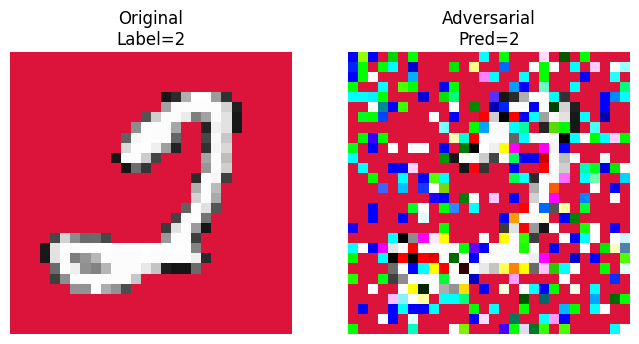

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
to_tensor, to_pil = transforms.ToTensor(), transforms.ToPILImage()
torch.manual_seed(42)

challenge_dir = Path('../data/MNIST/challenge')
out_dir = challenge_dir / 'edited'
out_dir.mkdir(parents=True, exist_ok=True)

def optimizador_ruido(model, x0, target, steps=200, sigma=1.0, alpha=2.0, pct=0.4):
    
    model.eval()

    # normalizar forma a [1,C,H,W]
    if x0.dim() == 3:
        x = x0.unsqueeze(0).clone().detach().to(device)
    else:
        x = x0.clone().detach().to(device)

    x0 = x.clone().detach()
    best_x = x.clone()

    _, C, H, W = x.shape
    k = int(pct * H * W)

    for step in range(steps):
        # creamos la imagen con ruido
        noise = torch.randn_like(x, device=device)

        # evaluamos +noise y -noise
        x_plus = (x + sigma * noise).clamp(0, 1)
        x_minus = (x - sigma * noise).clamp(0, 1)

        s_plus = F.softmax(model(x_plus), dim=1)[0, target].item()
        s_minus = F.softmax(model(x_minus), dim=1)[0, target].item()

        if s_plus - s_minus > 0:
            est_grad = noise
        else: 
            est_grad = -noise

        # paso de actualización
        x_new = (x + alpha * est_grad).clamp(0, 1)

        # conservar solo los k píxeles con mayor cambio
        diff = (x_new - x0).abs().sum(1, keepdim=True)
        flat = diff.view(-1)
        if k < flat.numel():
            th = torch.topk(flat, k).values.min()
            mask = (diff >= th).float()
        else:
            mask = torch.ones_like(diff)

        mask = mask.repeat(1, C, 1, 1) 
        x_new = x0 * (1 - mask) + x_new * mask

        # evaluar
        score_new = F.softmax(model(x_new), dim=1)[0, target].item()
        best_x = x_new.clone()

        x = x_new.clone().detach()

        if step % 10 == 0:
            print(f"step {step:3d}: target prob={score_new:.4f}")

        # early stop si la predicción ya es la clase objetivo
        if model(x).argmax(1).item() == target:
            print(f"✅ Target class {target} achieved at step {step}")
            break

    return best_x.squeeze(0).cpu()


for img_path in challenge_dir.glob('*.png'):
    img = to_tensor(Image.open(img_path)).unsqueeze(0).to(device)
    true_label = int(img_path.stem[-1])

    adv_img = optimizador_ruido(model, img, true_label, steps=200, pct=0.4)
    adv_pred = model(adv_img.unsqueeze(0).to(device)).argmax(dim=1).item()

    print(f"{img_path.name}: True={true_label}, Adv Pred={adv_pred}, Target={true_label}")
    # Guardar imagen adversarial
    adv_pil = to_pil(adv_img.squeeze())
    adv_pil.save(out_dir / img_path.name)

    # Mostrar comparación
    fig, axs = plt.subplots(1, 2, figsize=(8,4))
    axs[0].imshow(to_pil(img.squeeze().cpu())); axs[0].set_title(f"Original\nLabel={true_label}")
    axs[1].imshow(adv_pil); axs[1].set_title(f"Adversarial\nPred={adv_pred}")
    for ax in axs: ax.axis('off')
    plt.show()

---
## Check if you have passed the challenge 

In [90]:
# Create edited directory
edited_dir = challenge_dir / 'edited'

# Load edited images, check that they are predicted correctly and calculate edit percentages
for original_img_file, edited_img_file in zip(challenge_dir.glob('*.png'), edited_dir.glob('*.png')):
    original_img = Image.open(original_img_file)
    edited_img = Image.open(edited_img_file)
    # Convert the edited image to RGB if it's not
    if edited_img.mode != 'RGB':
        edited_img = edited_img.convert('RGB')

    # Check prediction
    img_tensor = to_tensor(edited_img).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(img_tensor)
        pred = output.argmax(dim=1).item()
    
    print(f'Edited {edited_img_file.name}: Pred: {pred}, Label: {original_img_file.stem[-1]}, correct: {pred == int(original_img_file.stem[-1])}')

    # Calculate edit percentage
    edit_percentage = calculate_edit_percentage(original_img, edited_img)
    print(f'Edit Percentage: {edit_percentage:.2f}%')


Edited 0_label5.png: Pred: 5, Label: 5, correct: True
Edit Percentage: 39.92%
Edited 1_label3.png: Pred: 3, Label: 3, correct: True
Edit Percentage: 39.92%
Edited 2_label3.png: Pred: 3, Label: 3, correct: True
Edit Percentage: 39.92%
Edited 3_label7.png: Pred: 7, Label: 7, correct: True
Edit Percentage: 39.92%
Edited 4_label2.png: Pred: 2, Label: 2, correct: True
Edit Percentage: 39.92%
